# 🔬 BLT-LAD: Byte Latent Transformer for Log Anomaly Detection

A log anomaly detection model based on Meta AI's **Byte Latent Transformer (BLT)** architecture.
Operates directly on **raw bytes** using **Shannon entropy** to divide each log line into
predictable (low-entropy) and unpredictable (high-entropy) patches.

**Dataset**: BGL (Blue Gene/L Supercomputer Logs — full dataset)  
**Pipeline**: `Raw bytes → Entropy Patcher → Local Encoder → Global Transformer → Entropy-Aware Aggregator → Classifier`

## 1. Imports & Setup

In [1]:
import os, sys, time, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {device}', flush=True)


PyTorch 2.8.0+cu126 | Device: cuda


## 2. Configuration

Scaled-up config — ~12-15x larger than the minimal baseline.

In [2]:
@dataclass
class BLTLADConfig:
    # ── Data ──
    max_bytes: int = 256        # bytes per log line
    patch_size: int = 8
    n_patches: int = 32         # max_bytes // patch_size
    # ── Entropy ──
    entropy_threshold: float = 1.5
    alpha: float = 2.0
    # ── Local Encoder ──
    vocab_size: int = 260       # 256 bytes + 4 special tokens
    dim_local: int = 256        # scaled up from 128
    n_heads_local: int = 4
    n_layers_local: int = 3     # scaled up from 2
    local_window: int = 8
    dropout: float = 0.1
    # ── Global Transformer ──
    dim_global: int = 512       # scaled up from 256
    n_heads_global: int = 8
    n_layers_global: int = 4    # scaled up from 3
    # ── Training ──
    lr: float = 3e-4
    batch_size: int = 32        # smaller batch to fit larger model
    epochs: int = 15            # more epochs with more capacity
    focal_gamma: float = 2.0
    # ── Misc ──
    seed: int = 42
    pad_byte: int = 0

config = BLTLADConfig()
torch.manual_seed(config.seed)
np.random.seed(config.seed)

print('Config:', flush=True)
for k, v in vars(config).items():
    print(f'  {k}: {v}')


Config:
  max_bytes: 256
  patch_size: 8
  n_patches: 32
  entropy_threshold: 1.5
  alpha: 2.0
  vocab_size: 260
  dim_local: 256
  n_heads_local: 4
  n_layers_local: 3
  local_window: 8
  dropout: 0.1
  dim_global: 512
  n_heads_global: 8
  n_layers_global: 4
  lr: 0.0003
  batch_size: 32
  epochs: 15
  focal_gamma: 2.0
  seed: 42
  pad_byte: 0


## 3. Load Full BGL Dataset

The full `BGL.log_structured.csv` has ~4.7 million rows (750 MB).  
We read it in **chunks** and keep a **stratified subsample** of 375K rows
(300K normal + 75K anomaly) to match the scaled-up model capacity.

Label `'-'` = Normal, anything else = Anomaly.

In [3]:
# ── Kaggle path (adjust dataset slug if needed) ──
KAGGLE_PATH = '/kaggle/input/datasets/prianshugarg/bgl-not-chomu/BGL.log_structured.csv'
LOCAL_PATH  = 'BGL/BGL.log_structured.csv'
DATA_PATH   = KAGGLE_PATH if os.path.exists(KAGGLE_PATH) else LOCAL_PATH
print(f'Loading from: {DATA_PATH}', flush=True)

# ── Stratified subsample — scaled to 375K total ──
MAX_NORMAL  = 300_000
MAX_ANOMALY =  75_000
CHUNK_SIZE  = 100_000

normal_parts, anomaly_parts = [], []
n_collected, a_collected = 0, 0

for chunk in pd.read_csv(
        DATA_PATH, usecols=['Label', 'Content'],
        chunksize=CHUNK_SIZE, on_bad_lines='skip', low_memory=False):
    chunk = chunk.dropna(subset=['Content'])
    chunk['is_anomaly'] = (chunk['Label'] != '-').astype(int)

    if n_collected < MAX_NORMAL:
        need = MAX_NORMAL - n_collected
        part = chunk[chunk.is_anomaly == 0].head(need)
        normal_parts.append(part)
        n_collected += len(part)

    if a_collected < MAX_ANOMALY:
        need = MAX_ANOMALY - a_collected
        part = chunk[chunk.is_anomaly == 1].head(need)
        anomaly_parts.append(part)
        a_collected += len(part)

    print(f'  chunk done | normal: {n_collected:,}/{MAX_NORMAL:,}'
          f' | anomaly: {a_collected:,}/{MAX_ANOMALY:,}', flush=True)

    if n_collected >= MAX_NORMAL and a_collected >= MAX_ANOMALY:
        print('  Target reached — stopping early.', flush=True)
        break

df = pd.concat(normal_parts + anomaly_parts, ignore_index=True)
del normal_parts, anomaly_parts
df = df.sample(frac=1.0, random_state=config.seed).reset_index(drop=True)

print(f'\nFinal dataset : {len(df):,} rows')
print(f'Normal        : {(df.is_anomaly==0).sum():,}')
print(f'Anomaly       : {(df.is_anomaly==1).sum():,} ({df.is_anomaly.mean()*100:.1f}%)')

split    = int(len(df) * 0.8)
train_df = df.iloc[:split].reset_index(drop=True)
test_df  = df.iloc[split:].reset_index(drop=True)
print(f'Train: {len(train_df):,} | Test: {len(test_df):,}', flush=True)


Loading from: /kaggle/input/datasets/prianshugarg/bgl-not-chomu/BGL.log_structured.csv
  chunk done | normal: 97,391/300,000 | anomaly: 2,609/75,000
  chunk done | normal: 197,231/300,000 | anomaly: 2,769/75,000
  chunk done | normal: 220,359/300,000 | anomaly: 75,000/75,000
  chunk done | normal: 227,633/300,000 | anomaly: 75,000/75,000
  chunk done | normal: 293,153/300,000 | anomaly: 75,000/75,000
  chunk done | normal: 300,000/300,000 | anomaly: 75,000/75,000
  Target reached — stopping early.

Final dataset : 375,000 rows
Normal        : 300,000
Anomaly       : 75,000 (20.0%)
Train: 300,000 | Test: 75,000


## 4. Dataset — Shannon Entropy Patching

In [4]:
def compute_patch_entropy(patch_bytes):
    if len(patch_bytes) == 0:
        return 0.0
    _, counts = np.unique(patch_bytes, return_counts=True)
    probs = counts / len(patch_bytes)
    return float(-np.sum(probs * np.log2(probs + 1e-12)))


class BGLByteDataset(Dataset):
    """Converts log lines to fixed 8-byte patches scored by Shannon entropy."""

    def __init__(self, dataframe, cfg):
        self.cfg      = cfg
        self.contents = dataframe['Content'].astype(str).tolist()
        self.labels   = dataframe['is_anomaly'].tolist()

    def __len__(self):
        return len(self.contents)

    def __getitem__(self, idx):
        cfg = self.cfg
        raw = self.contents[idx]

        byte_seq  = list(raw.encode('utf-8', errors='replace'))[:cfg.max_bytes]
        byte_seq += [cfg.pad_byte] * (cfg.max_bytes - len(byte_seq))
        byte_arr  = np.array(byte_seq, dtype=np.int64)

        patches     = byte_arr.reshape(cfg.n_patches, cfg.patch_size)
        entropies   = np.array([compute_patch_entropy(p) for p in patches], dtype=np.float32)
        patch_types = (entropies >= cfg.entropy_threshold).astype(np.int64)

        return (
            torch.tensor(byte_arr,    dtype=torch.long),
            torch.tensor(patch_types, dtype=torch.long),
            torch.tensor(entropies,   dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )


train_ds = BGLByteDataset(train_df, config)
test_ds  = BGLByteDataset(test_df,  config)

train_loader = DataLoader(train_ds, batch_size=config.batch_size, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=config.batch_size, shuffle=False, num_workers=2, pin_memory=True)

tokens, pt, ev, lbl = train_ds[0]
print(f'tokens:     {tokens.shape}')
print(f'patch_type: {pt.shape}')
print(f'entropy[0:8]: {ev[:8].numpy().round(2)}')
print(f'label: {lbl.item()} ({"Anomaly" if lbl else "Normal"})')
print(f'HE patches: {pt.sum().item()}/{config.n_patches}')


tokens:     torch.Size([256])
patch_type: torch.Size([32])
entropy[0:8]: [ 2.75  3.    2.   -0.   -0.   -0.   -0.   -0.  ]
label: 0 (Normal)
HE patches: 3/32


## 5. Entropy Visualization

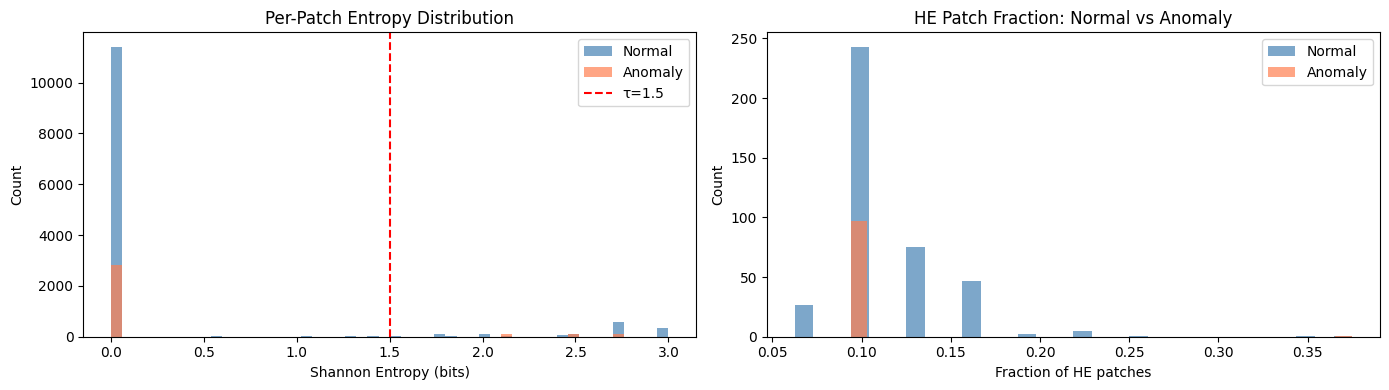

In [5]:
sample_n = min(500, len(train_ds))
normal_ent, anomaly_ent = [], []
for i in range(sample_n):
    _, _, ev, lbl = train_ds[i]
    (anomaly_ent if lbl.item() else normal_ent).extend(ev.numpy().tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(normal_ent,  bins=50, alpha=0.7, color='steelblue', label='Normal')
axes[0].hist(anomaly_ent, bins=50, alpha=0.7, color='coral',     label='Anomaly')
axes[0].axvline(config.entropy_threshold, color='red', ls='--', label=f'τ={config.entropy_threshold}')
axes[0].set_xlabel('Shannon Entropy (bits)'); axes[0].set_ylabel('Count')
axes[0].set_title('Per-Patch Entropy Distribution'); axes[0].legend()

fracs_n, fracs_a = [], []
for i in range(sample_n):
    _, pt, _, lbl = train_ds[i]
    (fracs_a if lbl.item() else fracs_n).append(pt.float().mean().item())

axes[1].hist(fracs_n, bins=30, alpha=0.7, color='steelblue', label='Normal')
axes[1].hist(fracs_a, bins=30, alpha=0.7, color='coral',     label='Anomaly')
axes[1].set_xlabel('Fraction of HE patches'); axes[1].set_ylabel('Count')
axes[1].set_title('HE Patch Fraction: Normal vs Anomaly'); axes[1].legend()

plt.tight_layout(); plt.show()


## 6. BLT-LAD Model

All components defined inline:
- **LocalEncoder** — sliding-window byte transformer (dim=128, 2 layers)
- **GlobalTransformer** — full self-attention over patches (dim=256, 3 layers)
- **EntropyAwareAggregator** — attention pooling weighted toward HE patches
- **ClassificationHead** — 2-class output

In [6]:
# ── Sliding Window Mask ──
def sliding_mask(seq_len, window, device):
    i = torch.arange(seq_len, device=device)
    return (i.unsqueeze(0) - i.unsqueeze(1)).abs() < window


class MHSAttention(nn.Module):
    def __init__(self, dim, n_heads, dropout=0.0, use_sw=False, window=8):
        super().__init__()
        self.n_heads  = n_heads
        self.head_dim = dim // n_heads
        self.use_sw   = use_sw
        self.window   = window
        self.qkv      = nn.Linear(dim, 3 * dim, bias=False)
        self.out      = nn.Linear(dim, dim, bias=False)
        self.drop     = nn.Dropout(dropout)
        self.scale    = self.head_dim ** -0.5

    def forward(self, x, mask=None):
        B, S, D = x.shape
        q, k, v = self.qkv(x).reshape(B, S, 3, self.n_heads, self.head_dim).unbind(2)
        q, k, v = [t.transpose(1, 2) for t in (q, k, v)]
        a = (q @ k.transpose(-2, -1)) * self.scale
        if self.use_sw:
            mask = sliding_mask(S, self.window, x.device)
        if mask is not None:
            if mask.dim() == 2:
                mask = mask.unsqueeze(0).unsqueeze(0)
            a = a.masked_fill(~mask, float('-inf'))
        a = self.drop(F.softmax(a, dim=-1))
        return self.out((a @ v).transpose(1, 2).reshape(B, S, D))


class TBlock(nn.Module):
    def __init__(self, dim, n_heads, dropout=0.0, use_sw=False, window=8):
        super().__init__()
        self.n1  = nn.RMSNorm(dim)
        self.attn= MHSAttention(dim, n_heads, dropout, use_sw, window)
        self.n2  = nn.RMSNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim*4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim*4, dim), nn.Dropout(dropout),
        )
    def forward(self, x, mask=None):
        x = x + self.attn(self.n1(x), mask=mask)
        return x + self.ffn(self.n2(x))


class RoPE(nn.Module):
    def __init__(self, dim, base=10000.0):
        super().__init__()
        self.register_buffer('inv_freq',
            1.0 / (base ** (torch.arange(0, dim, 2).float() / dim)))
    def forward(self, n):
        t = torch.arange(n, device=self.inv_freq.device, dtype=self.inv_freq.dtype)
        f = torch.outer(t, self.inv_freq)
        return torch.cat([f.sin(), f.cos()], dim=-1)


class LocalEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg      = cfg
        self.byte_emb = nn.Embedding(cfg.vocab_size, cfg.dim_local)
        self.type_emb = nn.Embedding(2, cfg.dim_local)
        self.rope     = RoPE(cfg.dim_local)
        self.layers   = nn.ModuleList([
            TBlock(cfg.dim_local, cfg.n_heads_local, cfg.dropout, use_sw=True, window=cfg.local_window)
            for _ in range(cfg.n_layers_local)
        ])
        self.norm = nn.RMSNorm(cfg.dim_local)

    def forward(self, tokens, patch_type):
        B, cfg = tokens.shape[0], self.cfg
        h  = self.byte_emb(tokens) + self.rope(cfg.max_bytes).unsqueeze(0)
        te = self.type_emb(patch_type).unsqueeze(2)
        te = te.expand(-1, -1, cfg.patch_size, -1).reshape(B, cfg.max_bytes, cfg.dim_local)
        h += te
        for layer in self.layers:
            h = layer(h)
        h = self.norm(h)
        return h.reshape(B, cfg.n_patches, cfg.patch_size, cfg.dim_local).mean(2)


class GlobalTransformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.proj  = nn.Linear(cfg.dim_local, cfg.dim_global, bias=False)
        self.layers= nn.ModuleList([
            TBlock(cfg.dim_global, cfg.n_heads_global, cfg.dropout)
            for _ in range(cfg.n_layers_global)
        ])
        self.norm  = nn.RMSNorm(cfg.dim_global)
    def forward(self, x):
        h = self.proj(x)
        for l in self.layers: h = l(h)
        return self.norm(h)


class EntropyAwareAggregator(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.alpha  = cfg.alpha
        self.pool_w = nn.Linear(cfg.dim_global, 1, bias=False)
    def forward(self, h, patch_type):
        scores  = self.pool_w(h).squeeze(-1) + self.alpha * patch_type.float()
        weights = F.softmax(scores, dim=-1)
        return (h * weights.unsqueeze(-1)).sum(1)


class ClassificationHead(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        d = cfg.dim_global
        self.net = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d//2), nn.GELU(), nn.Dropout(cfg.dropout),
            nn.Linear(d//2, 2),
        )
    def forward(self, x): return self.net(x)


class BLTLogAnomalyDetector(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.local  = LocalEncoder(cfg)
        self.global_= GlobalTransformer(cfg)
        self.agg    = EntropyAwareAggregator(cfg)
        self.head   = ClassificationHead(cfg)

    def forward(self, tokens, patch_type):
        pe = self.local(tokens, patch_type)
        hg = self.global_(pe)
        lr = self.agg(hg, patch_type)
        return self.head(lr)

    def n_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


model = BLTLogAnomalyDetector(config).to(device)
print(f'Parameters: {model.n_params():,}', flush=True)


Parameters: 15,294,210


## 7. Focal Loss, Optimizer & Training Utilities

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        return (((1 - torch.exp(-ce)) ** self.gamma) * ce).mean()


def train_epoch(model, loader, optimizer, scheduler, criterion, device, epoch, total):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    nb = len(loader)
    log_every = max(1, nb // 10)   # print ~10 times per epoch
    t0 = time.time()
    for i, (tok, pt, _, lbl) in enumerate(loader):
        tok, pt, lbl = tok.to(device), pt.to(device), lbl.to(device)
        optimizer.zero_grad()
        out  = model(tok, pt)
        loss = criterion(out, lbl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler: scheduler.step()
        total_loss += loss.item() * lbl.size(0)
        correct    += (out.argmax(-1) == lbl).sum().item()
        n          += lbl.size(0)
        if (i+1) % log_every == 0 or i == nb-1:
            elapsed = time.time() - t0
            eta     = elapsed / (i+1) * (nb - i - 1)
            print(f'  Ep {epoch}/{total} [{i+1:>4}/{nb}]'
                  f'  loss={loss.item():.4f}'
                  f'  acc={correct/n:.3f}'
                  f'  ETA {eta:.0f}s', flush=True)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    preds, labels, probs = [], [], []
    for tok, pt, _, lbl in loader:
        tok, pt, lbl = tok.to(device), pt.to(device), lbl.to(device)
        out = model(tok, pt)
        total_loss += criterion(out, lbl).item() * lbl.size(0)
        probs.extend(F.softmax(out, -1)[:,1].cpu().numpy())
        preds.extend(out.argmax(-1).cpu().numpy())
        labels.extend(lbl.cpu().numpy())
    preds, labels, probs = map(np.array, (preds, labels, probs))
    n = len(labels)
    m = {
        'loss':      total_loss / n,
        'accuracy':  (preds == labels).mean(),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),
        'f1':        f1_score(labels, preds, zero_division=0),
        'roc_auc':   roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else 0.0,
    }
    report = classification_report(labels, preds, target_names=['Normal','Anomaly'], zero_division=0)
    return m, report


# ── Setup ──
n_normal  = train_ds.labels.count(0)
n_anomaly = train_ds.labels.count(1)
weight    = torch.tensor([1.0, n_normal / max(n_anomaly, 1)], device=device)
criterion = FocalLoss(gamma=config.focal_gamma, weight=weight)

optimizer    = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=0.01)
total_steps  = len(train_loader) * config.epochs
scheduler    = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=config.lr, total_steps=total_steps, pct_start=0.1)

print(f'Class weights  — Normal: {weight[0]:.1f}, Anomaly: {weight[1]:.1f}')
print(f'Train batches  : {len(train_loader)}')
print(f'Total steps    : {total_steps}', flush=True)


Class weights  — Normal: 1.0, Anomaly: 4.0
Train batches  : 9375
Total steps    : 140625


## 8. Training Loop

In [8]:
history  = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_f1':[], 'val_recall':[]}
best_f1  = 0.0
CKPT     = '/kaggle/working/blt_lad_best.pt'

print(f'Training {config.epochs} epochs | {len(train_loader)} batches/epoch | device={device}', flush=True)

for epoch in range(1, config.epochs + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, device, epoch, config.epochs)
    val_m, _ = evaluate(model, test_loader, criterion, device)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_m['loss'])
    history['val_f1'].append(val_m['f1'])
    history['val_recall'].append(val_m['recall'])

    mark = ''
    if val_m['f1'] > best_f1:
        best_f1 = val_m['f1']
        torch.save(model.state_dict(), CKPT)
        mark = ' ★ saved'

    print(f'━━ Epoch {epoch:02d}/{config.epochs}'
          f' | Loss {tr_loss:.4f} Acc {tr_acc:.3f}'
          f' | Val F1 {val_m["f1"]:.3f} Rec {val_m["recall"]:.3f}'
          f' | {time.time()-t0:.0f}s{mark}', flush=True)

print(f'\nBest F1: {best_f1:.4f}', flush=True)


Training 15 epochs | 9375 batches/epoch | device=cuda
  Ep 1/15 [ 937/9375]  loss=0.0000  acc=0.977  ETA 883s
  Ep 1/15 [1874/9375]  loss=0.0000  acc=0.988  ETA 810s
  Ep 1/15 [2811/9375]  loss=0.0000  acc=0.992  ETA 716s
  Ep 1/15 [3748/9375]  loss=0.0001  acc=0.994  ETA 618s
  Ep 1/15 [4685/9375]  loss=0.0000  acc=0.995  ETA 517s
  Ep 1/15 [5622/9375]  loss=0.0000  acc=0.996  ETA 414s
  Ep 1/15 [6559/9375]  loss=0.0000  acc=0.996  ETA 311s
  Ep 1/15 [7496/9375]  loss=0.0000  acc=0.997  ETA 208s
  Ep 1/15 [8433/9375]  loss=0.0000  acc=0.997  ETA 104s
  Ep 1/15 [9370/9375]  loss=0.0000  acc=0.997  ETA 1s
  Ep 1/15 [9375/9375]  loss=0.0000  acc=0.997  ETA 0s
━━ Epoch 01/15 | Loss 0.0043 Acc 0.997 | Val F1 1.000 Rec 1.000 | 1120s ★ saved
  Ep 2/15 [ 937/9375]  loss=0.0000  acc=1.000  ETA 942s
  Ep 2/15 [1874/9375]  loss=0.0000  acc=1.000  ETA 837s
  Ep 2/15 [2811/9375]  loss=0.0000  acc=1.000  ETA 732s
  Ep 2/15 [3748/9375]  loss=0.5041  acc=0.806  ETA 627s
  Ep 2/15 [4685/9375]  loss=0.

## 9. Training Curves

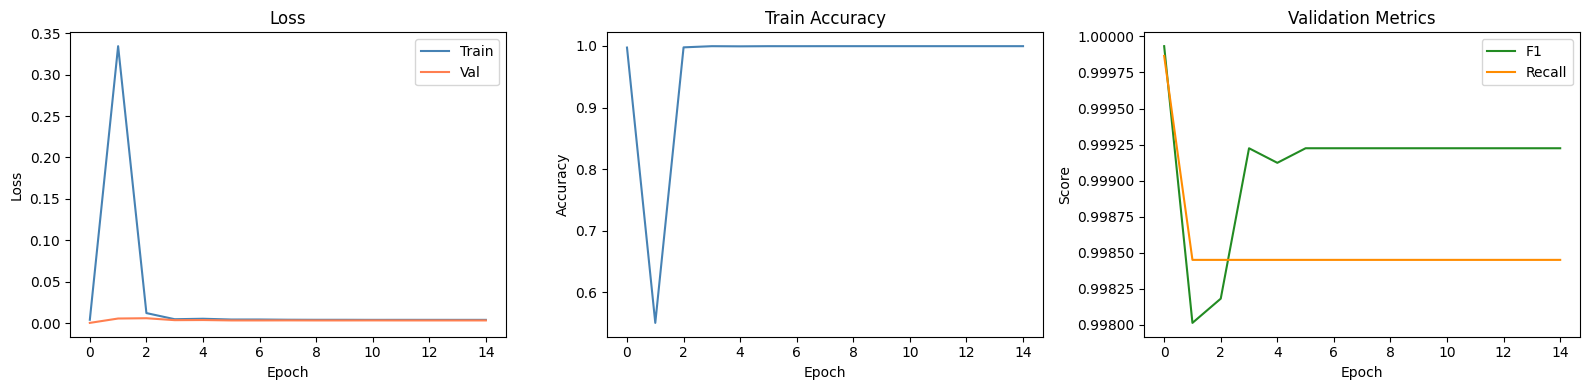

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history['train_loss'], label='Train', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val',   color='coral')
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Loss'); axes[0].legend()
axes[1].plot(history['train_acc'], color='steelblue')
axes[1].set(xlabel='Epoch', ylabel='Accuracy', title='Train Accuracy')
axes[2].plot(history['val_f1'],     label='F1',     color='forestgreen')
axes[2].plot(history['val_recall'], label='Recall', color='darkorange')
axes[2].set(xlabel='Epoch', ylabel='Score', title='Validation Metrics'); axes[2].legend()
plt.tight_layout(); plt.show()


## 10. Final Evaluation

In [1]:
model.load_state_dict(torch.load(CKPT, map_location=device, weights_only=True))
m, report = evaluate(model, test_loader, criterion, device)

print('=' * 55)
print('FINAL TEST RESULTS')
print('=' * 55)
for k, v in m.items():
    print(f'  {k:12s}: {v:.4f}')
print()
print(report)

# Confusion matrix
model.eval()
all_p, all_l = [], []
with torch.no_grad():
    for tok, pt, _, lbl in test_loader:
        out = model(tok.to(device), pt.to(device))
        all_p.extend(out.argmax(-1).cpu().numpy())
        all_l.extend(lbl.numpy())
cm = confusion_matrix(all_l, all_p)
print(f'Confusion Matrix:')
print(f'  TN={cm[0,0]:,}  FP={cm[0,1]:,}')
print(f'  FN={cm[1,0]:,}  TP={cm[1,1]:,}')


NameError: name 'model' is not defined

## 11. Sample Predictions with Entropy Analysis

In [ ]:
model.eval()
for i in range(min(5, len(test_ds))):
    tok, pt, ev, lbl = test_ds[i]
    with torch.no_grad():
        out  = model(tok.unsqueeze(0).to(device), pt.unsqueeze(0).to(device))
        pred = out.argmax(-1).item()
        prob = F.softmax(out, -1)[0, 1].item()
    ok = '✅' if pred == lbl.item() else '❌'
    print(f'{ok} [{"ANOMALY" if lbl.item() else "NORMAL "}→{"ANOMALY" if pred else "NORMAL "}]'
          f'  p={prob:.3f}  HE={pt.sum().item()}/{config.n_patches}  H={ev.mean():.2f}bits')
    print(f'   {test_df.iloc[i]["Content"][:90]}')
    print()


## 12. Architecture Summary

| Component | Detail |
|---|---|
| **Input** | Raw UTF-8 bytes, truncated to 256 bytes |
| **Entropy Patcher** | 8-byte fixed patches → Shannon entropy → LE/HE type (τ=1.5 bits) |
| **Local Encoder** | 2-layer sliding-window transformer, dim=128, RoPE |
| **Global Transformer** | 3-layer full self-attention over 32 patches, dim=256 |
| **Aggregator** | Attention-weighted pool biased toward HE patches (α=2.0) |
| **Classifier** | LayerNorm → Linear → GELU → Linear → 2 classes |
| **Loss** | Focal Loss (γ=2.0) + class weighting for imbalance |

### Dataset subsampling (for 750MB full BGL)
120K normal + 30K anomaly rows → 150K total, 80/20 train/test split.